# Proyecto Final - Análisis de Egresos Hospitalarios

Los egresos hospitalarios constituyen una fuente relevante de información para comprender el comportamiento del sistema de salud y las características de la población asistida. En este proyecto se realizará un Análisis Exploratorio de Datos (EDA) sobre un conjunto de datos de egresos hospitalarios registrados en Uruguay entre los años 2021 y 2024.

## Paso 1: Definición del problema u Objetivos

Antes de comenzar con el análisis de datos, se presenta el desafío que estaremos intentando resolver con la información presentada.
En este caso, trabajamos con un conjunto de datos de Egresos hospitalarios y las preguntas que intentaremos resolver serán las siguientes:
- ¿Cómo evolucionaron los egresos hospitalarios entre 2021 y 2024?
- ¿Existen diferencias en la distribución por género?
- ¿Qué diagnósticos son los más frecuentes?
- ¿Cómo se distribuyen los egresos entre regiones?
- ¿Qué participación tiene cada sector de atención?

## Paso 2: Importar Librerías

In [1]:
## Importación de librerias a utilizar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest

## Paso 3: Recopilación de datos
> Dataset de [Egresos_Hospitalarios]

#### Importamos los datos y creamos el DataFrame


In [2]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/NatyUCU/Project_Phyton_UCU/main/data/raw/p4ds_grupo_c_egresos_hospitalarios.csv",
    sep=";")
df


,ID,AÑO,SECTOR,GENERO,GRUPO ETAREO,REGION,DIAGNOSTICO,CAUSA EXTERNA
0,1,2024,PRIVADO,F,65+,INTERIOR,Hemorragia intracraneal,NC
1,2,2024,PRIVADO,M,65+,INTERIOR,Tumor maligno de la vejiga urinaria,NC
2,3,2024,PRIVADO,M,65+,INTERIOR,Otras enfermedades del sistema urinario,NC
3,4,2024,PRIVADO,F,65+,INTERIOR,Otras enfermedades del sistema urinario,NC
4,5,2024,PRIVADO,M,65+,INTERIOR,Otras enfermedades del sistema urinario,NC
...,...,...,...,...,...,...,...,...
1132006,307813,2024,PUBLICO,M,Menor a 1,MONTEVIDEO,Otros trastornos respiratorios originados en e...,NC
1132007,3163016,2022,PRIVADO,M,25 a 44,INTERIOR,Trastornos mentales y del comportamiento debid...,NC
1132008,40505,2024,PRIVADO,M,5 a 9,INTERIOR,99,NC
1132009,3587181,2023,PRIVADO,M,25 a 44,INTERIOR,Fracturas de otros huesos de los miembros,Accidentes de transporte


## Paso 3: Análisis Descriptivo
Antes de comenzar el análisis es importante conocer la estructura general del dataset, la cantidad de registros disponibles y los tipos de datos presentes en cada variable.

In [3]:
df.info() # Obtener información sobre tipos de datos y valores no nulos
df.describe()
df.shape # Obtener las dimensiones
print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")
df.sample(5)

<class 'pandas.DataFrame'>
RangeIndex: 1132011 entries, 0 to 1132010
Data columns (total 8 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   ID             1132011 non-null  int64
 1   AÑO            1132011 non-null  int64
 2   SECTOR         1132011 non-null  str  
 3   GENERO         1132011 non-null  str  
 4   GRUPO ETAREO   1132011 non-null  str  
 5   REGION         1089284 non-null  str  
 6   DIAGNOSTICO    1132011 non-null  str  
 7   CAUSA EXTERNA  1132011 non-null  str  
dtypes: int64(2), str(6)
memory usage: 144.4 MB
Cantidad de filas: 1132011
Cantidad de columnas: 8


,ID,AÑO,SECTOR,GENERO,GRUPO ETAREO,REGION,DIAGNOSTICO,CAUSA EXTERNA
830705,3300988,2022,PRIVADO,M,25 a 44,MONTEVIDEO,Insuficiencia renal,NC
453109,3546850,2023,PUBLICO,F,1 a 4,INTERIOR,99,NC
1006287,2897996,2021,PUBLICO,M,45 a 64,MONTEVIDEO,Otras enfermedades bacterianas,NC
95543,95544,2024,PRIVADO,M,25 a 44,INTERIOR,Otras enfermedades del sistema digestivo,NC
472100,3565841,2023,PRIVADO,M,65+,MONTEVIDEO,Embolia y trombosis arteriales,NC


> ### Observaciones

A partir de la exploración inicial se observa que el conjunto de datos contiene información correspondiente a egresos hospitalarios registrados entre los años 2021 y 2024.

La mayoría de las variables son categóricas, por lo que gran parte del análisis se enfocará en el estudio de frecuencias y distribuciones.

## Paso 4: Limpieza de Datos

## Paso 5: Análisis de Variables

### Análisis bivariado

### Gráfico General de Egresos Hospitalarios

> Se analiza la cantidad de registros correspondientes a cada año disponible en el dataset.

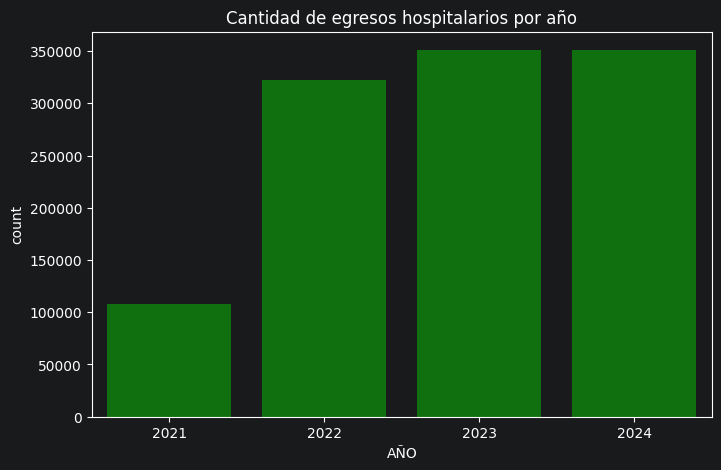

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="AÑO",
    color="green"
)

plt.title("Cantidad de egresos hospitalarios por año")
plt.show()

#### Distribución por Género

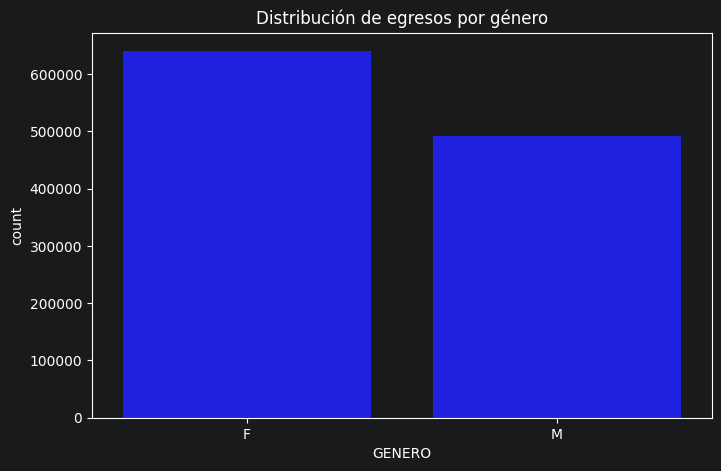

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="GENERO",
    color="blue"
)

plt.title("Distribución de egresos por género")
plt.show()

#### Distribución por SECTOR

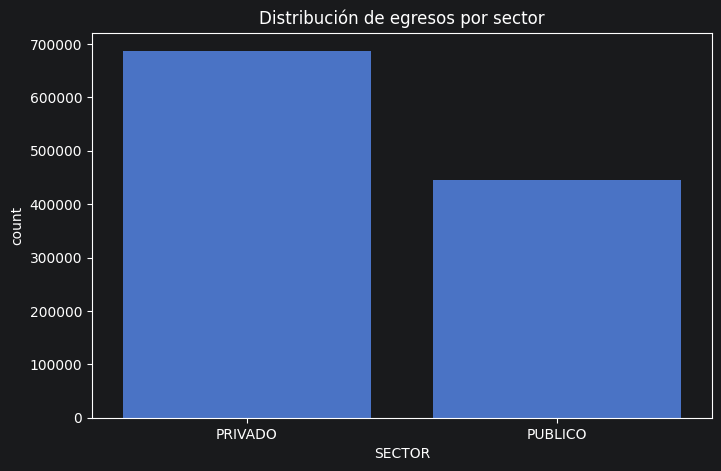

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="SECTOR"
)

plt.title("Distribución de egresos por sector")
plt.show()

### Distribución por Grupo Etário

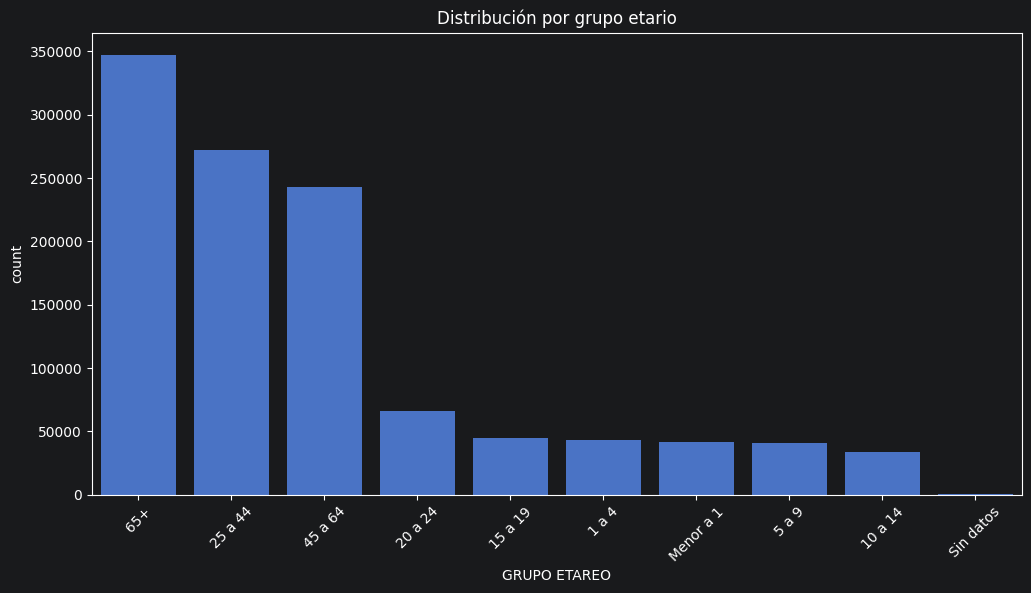

In [7]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="GRUPO ETAREO",
    order=df["GRUPO ETAREO"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Distribución por grupo etario")
plt.show()

> ### Observaciones

La distribución por grupo etario permite identificar cuáles son los segmentos de población con mayor presencia dentro de los egresos hospitalarios registrados.

### Diagnósticos mas frecuentes
> El análisis de diagnósticos permite identificar las principales causas de egreso hospitalario registradas en el período estudiado.

In [8]:
df["DIAGNOSTICO"].value_counts().head(15)

DIAGNOSTICO
Otras complicaciones del embarazo y del parto                                                                    53952
Parto único espontáneo                                                                                           43298
Colelitiasis y colecistitis                                                                                      43088
99                                                                                                               37833
Neumonía                                                                                                         34831
Otras enfermedades del sistema respiratorio                                                                      29445
Fracturas de otros huesos de los miembros                                                                        27587
Otros síntomas, signos y hallazgos anormales clínicos y de laboratorio, no clasificados en otra parte            24150
Enfermedades del apéndice           

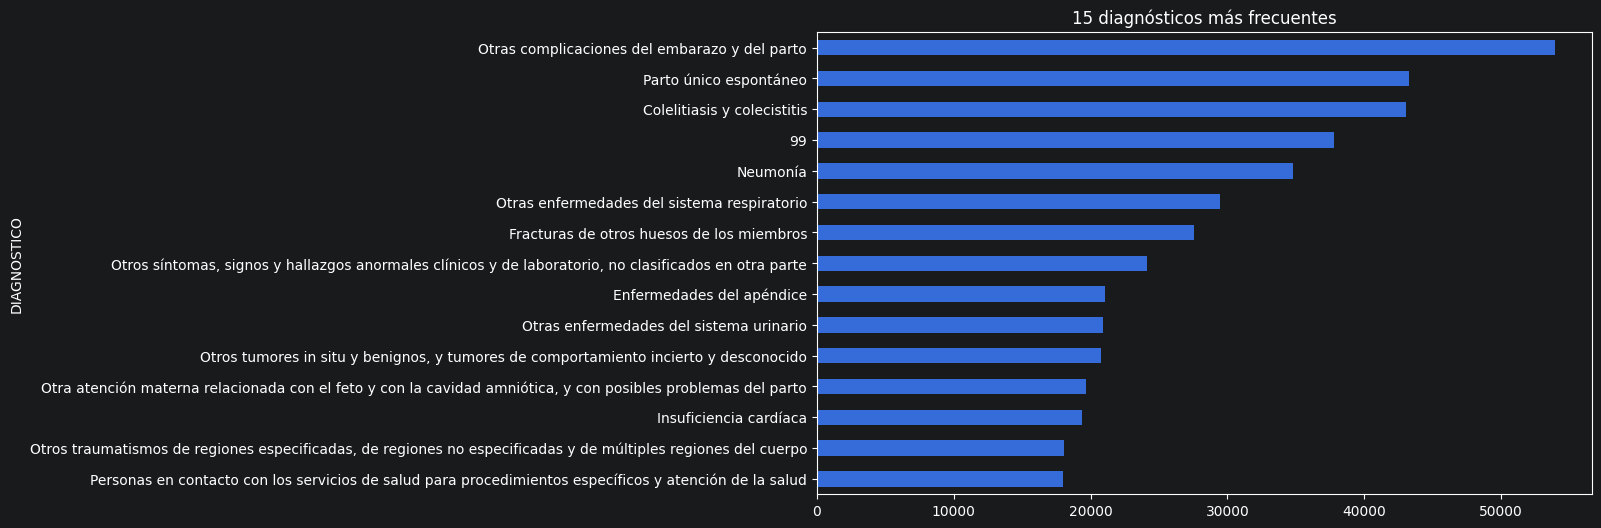

In [9]:
top_diag = (
    df["DIAGNOSTICO"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,6))

top_diag.sort_values().plot(kind="barh")

plt.title("15 diagnósticos más frecuentes")
plt.show()

### Se excluye codigo 99:
>Durante la exploración inicial se identificó la presencia del código 99 dentro de los diagnósticos.
Debido a que este código suele utilizarse para representar información no especificada o sin clasificar, se realizará un análisis adicional excluyéndolo para observar con mayor claridad los diagnósticos predominantes.

In [10]:
df_diag = df[
    df["DIAGNOSTICO"] != "99"
]

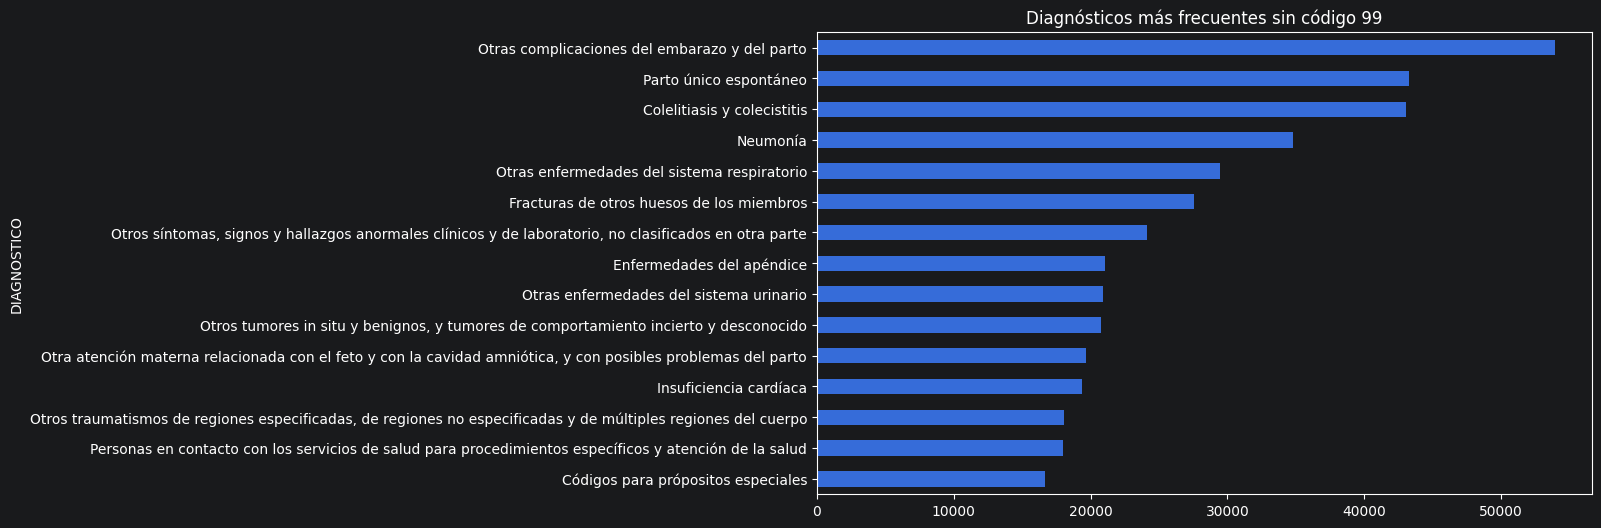

In [11]:
top_diag = (
    df_diag["DIAGNOSTICO"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,6))

top_diag.sort_values().plot(kind="barh")

plt.title("Diagnósticos más frecuentes sin código 99")
plt.show()

In [12]:
freq_diag = (
    df_diag.groupby("DIAGNOSTICO")
    .size()
    .reset_index(name="EGRESOS")
)

In [13]:
media = freq_diag["EGRESOS"].mean()
mediana = freq_diag["EGRESOS"].median()
moda = freq_diag["EGRESOS"].mode()[0]

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}")

Media: 4257.50
Mediana: 1505.0
Moda: 5


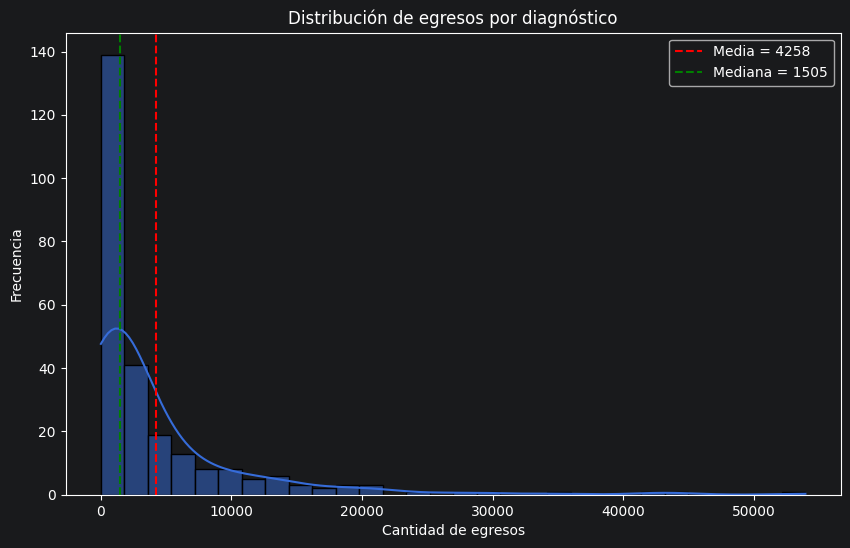

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    freq_diag["EGRESOS"],
    bins=30,
    kde=True
)

plt.axvline(
    media,
    color="red",
    linestyle="--",
    label=f"Media = {media:.0f}"
)

plt.axvline(
    mediana,
    color="green",
    linestyle="--",
    label=f"Mediana = {mediana:.0f}"
)

plt.title("Distribución de egresos por diagnóstico")
plt.xlabel("Cantidad de egresos")
plt.ylabel("Frecuencia")

plt.legend()

plt.show()

In [15]:
freq_diag.sort_values(
    by="EGRESOS",
    ascending=False
).head(10)

,DIAGNOSTICO,EGRESOS
115,Otras complicaciones del embarazo y del parto,53952
185,Parto único espontáneo,43298
22,Colelitiasis y colecistitis,43088
108,Neumonía,34831
137,Otras enfermedades del sistema respiratorio,29445
76,Fracturas de otros huesos de los miembros,27587
164,"Otros síntomas, signos y hallazgos anormales c...",24150
55,Enfermedades del apéndice,21054
138,Otras enfermedades del sistema urinario,20922
175,"Otros tumores in situ y benignos, y tumores de...",20797


#### Observaciones:
>La distribución de egresos por diagnóstico presenta una marcada asimetría positiva.
* La media de egresos por diagnóstico (4.104) es considerablemente superior a la mediana (1.455), lo que indica que existen algunos diagnósticos con una frecuencia excepcionalmente alta respecto al resto.
* La mayoría de los diagnósticos concentra una cantidad relativamente baja de egresos, mientras que un grupo reducido acumula una proporción importante de los registros hospitalarios.
* Este comportamiento sugiere la presencia de posibles valores atípicos, aspecto que será analizado con mayor detalle mediante el boxplot y la detección de outliers.

## Análisis bivariado
> Género y diagnóstico

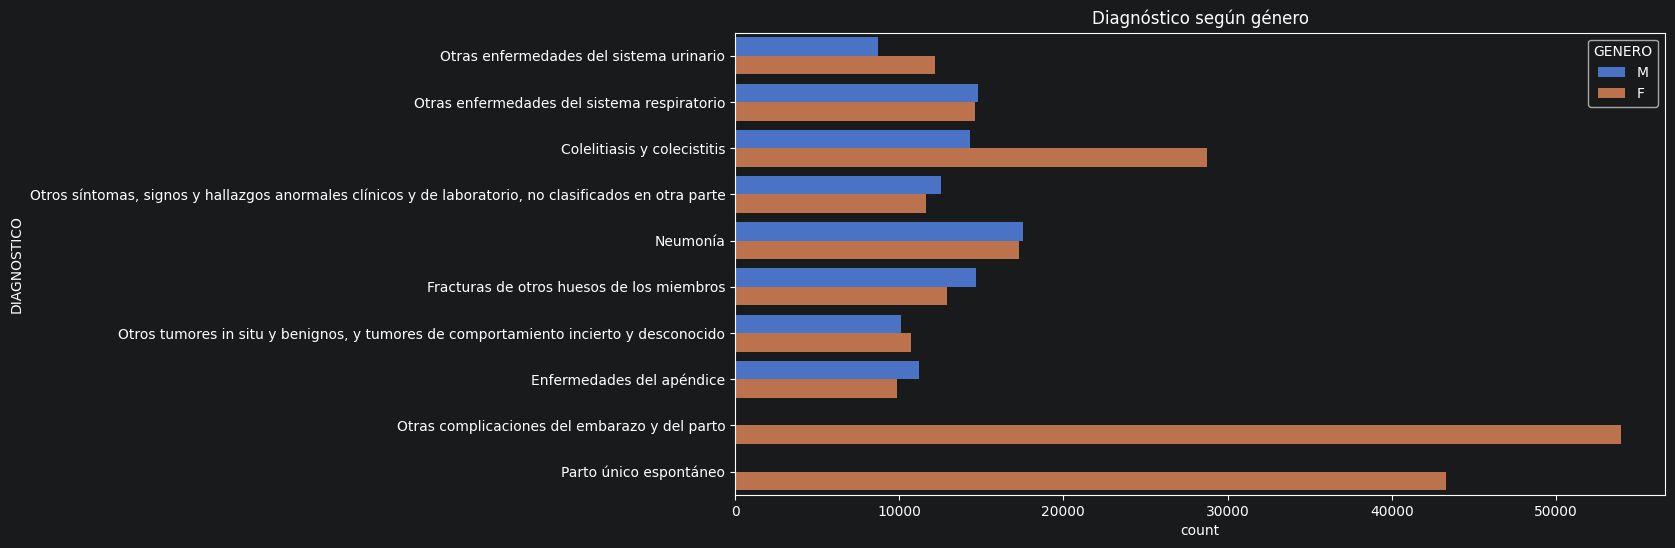

In [16]:
top10 = (
    df_diag["DIAGNOSTICO"]
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(12,6))

sns.countplot(
    data=df_diag[df_diag["DIAGNOSTICO"].isin(top10)],
    y="DIAGNOSTICO",
    hue="GENERO"
)

plt.title("Diagnóstico según género")
plt.show()

>Región y Sector

In [17]:
tabla = pd.crosstab(
    df["REGION"],
    df["SECTOR"]
)
tabla

SECTOR,PRIVADO,PUBLICO
REGION,,
EXTERIOR,270,15
INTERIOR,380388,290020
MONTEVIDEO,283695,132181
Sin datos,943,1772


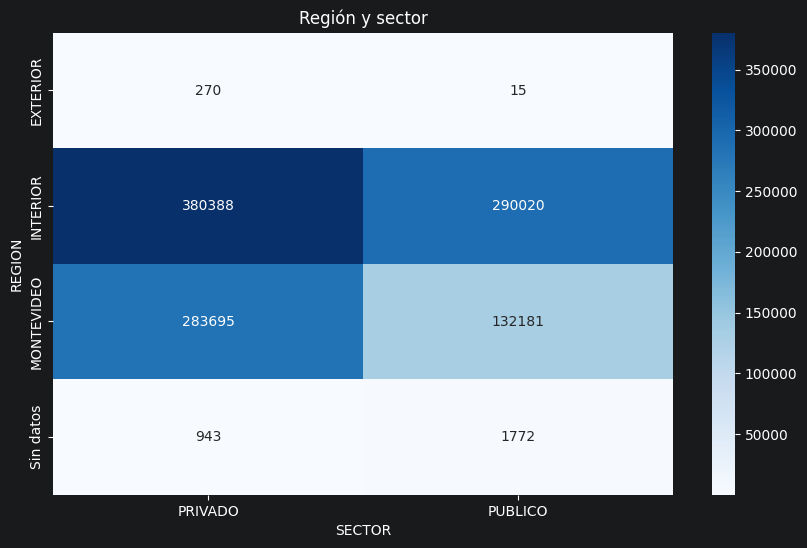

In [18]:
plt.figure(figsize=(10,6))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Región y sector")
plt.show()

## Detección de valores atípicos

Debido a que el dataset está compuesto principalmente por variables categóricas, se construirá una variable derivada basada en la frecuencia de egresos por diagnóstico.

Esta métrica permitirá detectar diagnósticos con una cantidad de registros significativamente superior o inferior al comportamiento general.

In [19]:
freq_diag = (
    df_diag.groupby("DIAGNOSTICO")
           .size()
           .reset_index(name="EGRESOS")
)

freq_diag.head()

,DIAGNOSTICO,EGRESOS
0,Aborto espontáneo,2814
1,Aborto médico,4643
2,"Accidente vascular encefálico agudo, no especi...",4347
3,Afecciones hemorrágicas y otras enfermedades d...,2638
4,Anemias por deficiencia de hierro,1226


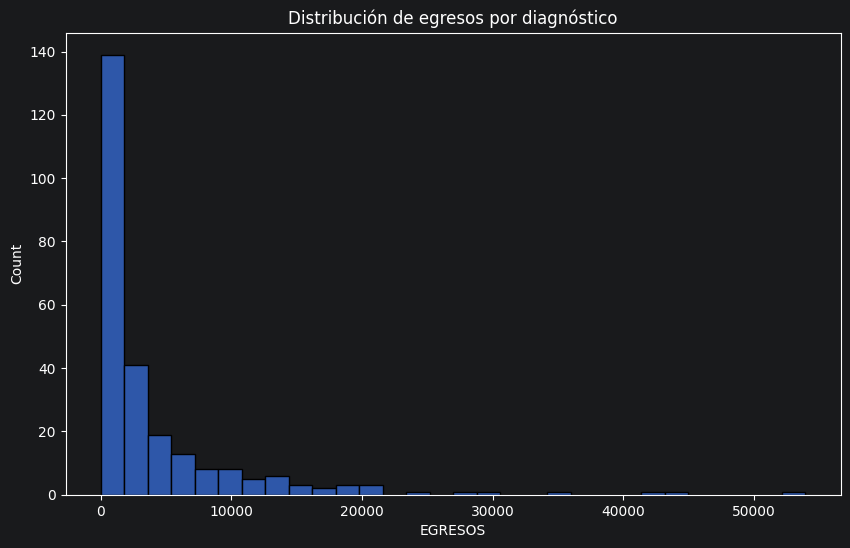

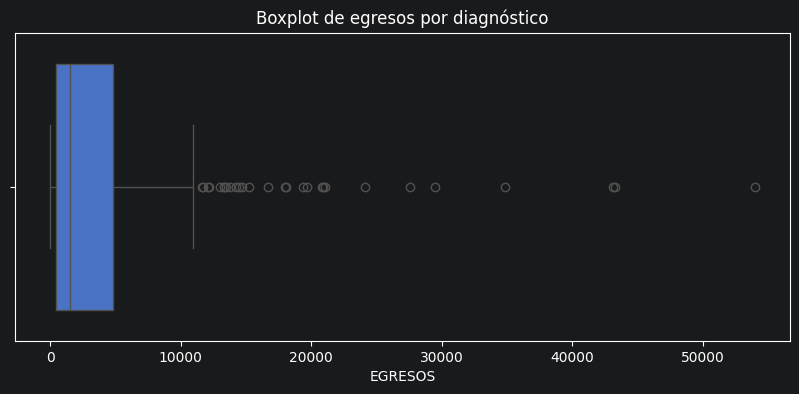

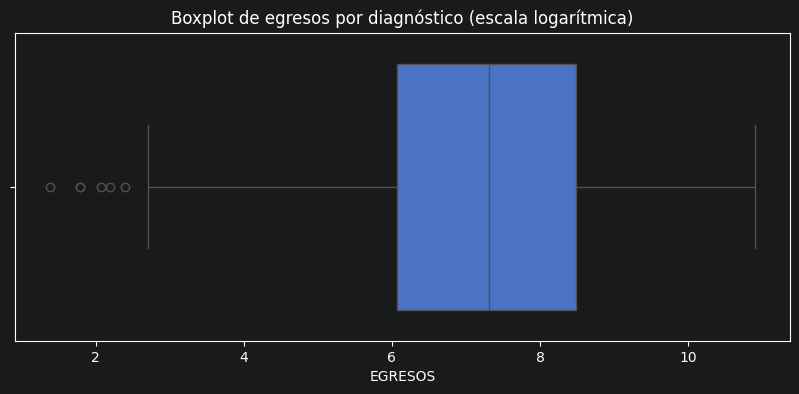

In [20]:
plt.figure(figsize=(10,6)) ###Histograma

sns.histplot(
    freq_diag["EGRESOS"],
    bins=30
)

plt.title("Distribución de egresos por diagnóstico")
plt.show()

plt.figure(figsize=(10,4))

sns.boxplot(
    x=freq_diag["EGRESOS"]
)

plt.title("Boxplot de egresos por diagnóstico")
plt.show()

plt.figure(figsize=(10,4))

sns.boxplot(
    x=np.log1p(freq_diag["EGRESOS"])
)

plt.title("Boxplot de egresos por diagnóstico (escala logarítmica)")
plt.show()


### Boxplot de egresos por diagnóstico

El boxplot permite visualizar la dispersión de la cantidad de egresos asociados a cada diagnóstico e identificar posibles valores atípicos.

## Detección de Outliers

In [21]:
Q1 = freq_diag["EGRESOS"].quantile(0.25)
Q3 = freq_diag["EGRESOS"].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = freq_diag[
    (freq_diag["EGRESOS"] < lim_inf) |
    (freq_diag["EGRESOS"] > lim_sup)
]

outliers.sort_values("EGRESOS", ascending=False)


,DIAGNOSTICO,EGRESOS
115,Otras complicaciones del embarazo y del parto,53952
185,Parto único espontáneo,43298
22,Colelitiasis y colecistitis,43088
108,Neumonía,34831
137,Otras enfermedades del sistema respiratorio,29445
76,Fracturas de otros huesos de los miembros,27587
164,"Otros síntomas, signos y hallazgos anormales c...",24150
55,Enfermedades del apéndice,21054
138,Otras enfermedades del sistema urinario,20922
175,"Otros tumores in situ y benignos, y tumores de...",20797


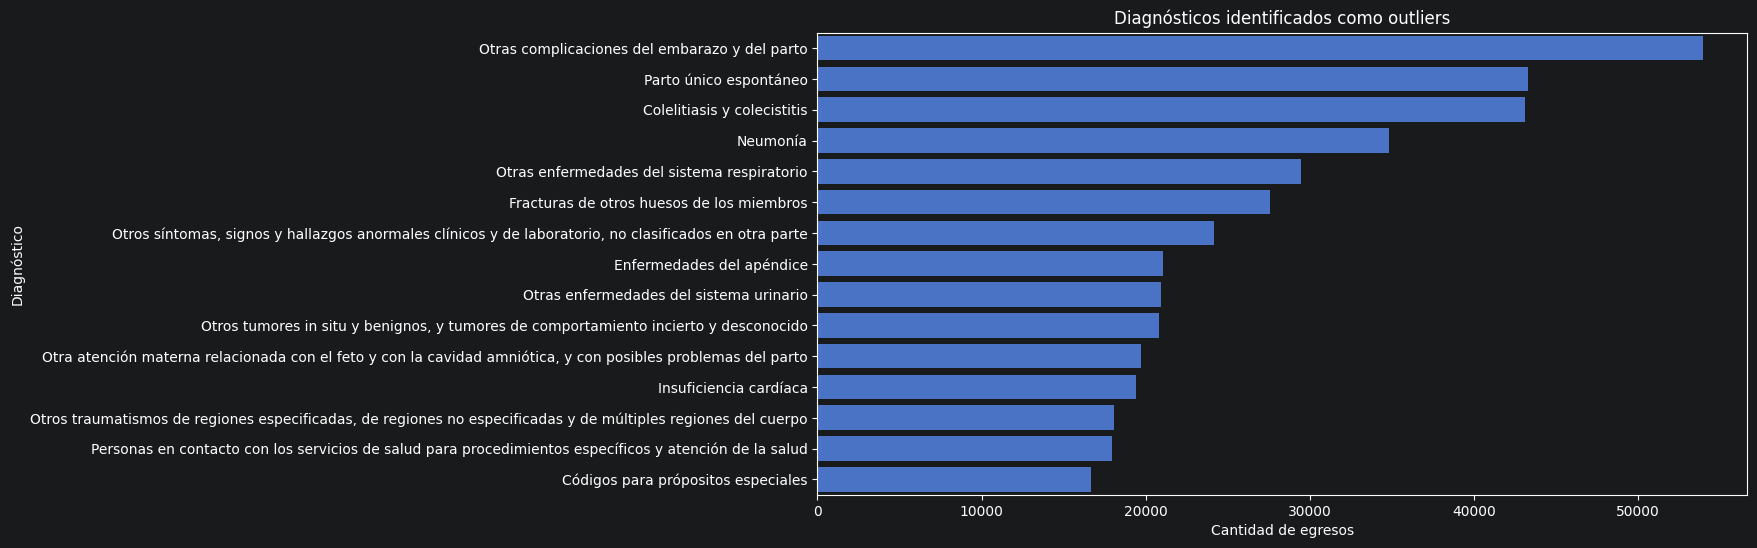

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=outliers.sort_values(
        "EGRESOS",
        ascending=False
    ).head(15),
    x="EGRESOS",
    y="DIAGNOSTICO"
)

plt.title("Diagnósticos identificados como outliers")
plt.xlabel("Cantidad de egresos")
plt.ylabel("Diagnóstico")

plt.show()



 > Observaciones

Los diagnósticos identificados como valores atípicos presentan una frecuencia considerablemente superior al resto de las categorías.
Esto indica que ciertas patologías concentran una proporción importante de los egresos hospitalarios registrados.

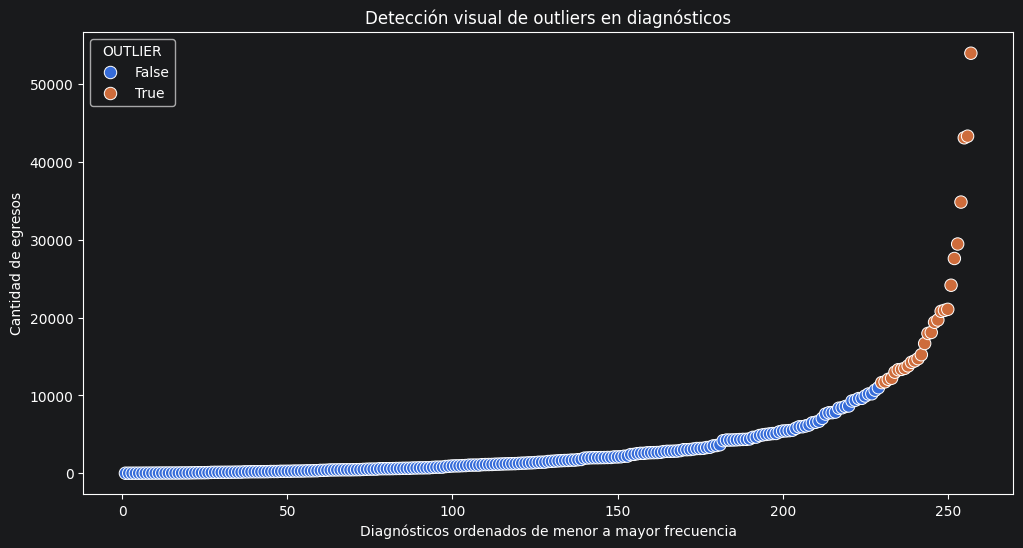

In [23]:
# Frecuencia de egresos por diagnóstico
freq_diag = (
    df_diag.groupby("DIAGNOSTICO")
           .size()
           .reset_index(name="EGRESOS")
           .sort_values("EGRESOS")
           .reset_index(drop=True)
)

# Ranking
freq_diag["RANK"] = range(1, len(freq_diag) + 1)

# Cálculo de outliers
Q1 = freq_diag["EGRESOS"].quantile(0.25)
Q3 = freq_diag["EGRESOS"].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

freq_diag["OUTLIER"] = (
    (freq_diag["EGRESOS"] < lim_inf) |
    (freq_diag["EGRESOS"] > lim_sup)
)

# Gráfico
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=freq_diag,
    x="RANK",
    y="EGRESOS",
    hue="OUTLIER",
    s=80
)

plt.title("Detección visual de outliers en diagnósticos")
plt.xlabel("Diagnósticos ordenados de menor a mayor frecuencia")
plt.ylabel("Cantidad de egresos")

plt.show()

#### Observación
> Diagrama de dispersión de diagnósticos

Con el objetivo de complementar el análisis de outliers, se construyó un diagrama de dispersión utilizando la frecuencia de egresos asociada a cada diagnóstico.

Los diagnósticos fueron ordenados según su cantidad de egresos y se identificaron visualmente aquellos que fueron clasificados como valores atípicos mediante el método del rango intercuartílico (IQR).

Esta visualización permite observar la magnitud de los outliers y su diferencia respecto al comportamiento general de la distribución.

## Conclusiones
El análisis exploratorio realizado permitió comprender la estructura y características principales de los egresos hospitalarios registrados en Uruguay entre los años 2021 y 2024.

Durante la etapa de calidad de datos se identificaron valores faltantes y registros repetidos. Sin embargo, el análisis de los identificadores evidenció que los registros aparentemente duplicados corresponden a eventos distintos, por lo que se decidió mantenerlos para preservar la representatividad del conjunto de datos.

Los análisis descriptivos mostraron que la distribución de los egresos no es uniforme entre las distintas categorías analizadas. Se observaron diferencias relevantes según grupo etario, género, sector asistencial y diagnóstico.

El estudio de los diagnósticos permitió identificar un conjunto reducido de categorías que concentra una proporción significativa de los egresos hospitalarios. Esta situación quedó reflejada en las medidas de tendencia central, donde la media resultó considerablemente superior a la mediana, evidenciando una distribución asimétrica.

Los análisis de outliers, realizados mediante histogramas, boxplots, diagramas de dispersión y el método del rango intercuartílico (IQR), confirmaron la existencia de diagnósticos con frecuencias excepcionalmente altas respecto al comportamiento general de los datos.

En conjunto, los resultados obtenidos proporcionan una visión integral del comportamiento de los egresos hospitalarios y constituyen una base sólida para futuras investigaciones, estudios epidemiológicos o desarrollos de modelos predictivos orientados al ámbito de la salud.

## Exportación de datos procesados

Se guarda una versión depurada del conjunto de datos para facilitar futuras etapas de análisis y modelado.

In [24]:
df_diag.to_csv(
    "egresos_hospitalarios_limpio_GrupoC.csv",
    index=False
)